# EDA: Features vs Target (`realized_car_hybrid`)

This notebook runs the same preprocessing pipeline as `model_realized.py` to produce the final pre-training dataframe, saves it to `data/model/eda_features.parquet`, and analyses every feature against the binary target (`alpha_above_threshold = realized_car_hybrid > 0`).

In [1]:
import sys, os

# Move to project root first so all relative paths resolve correctly
PROJECT_ROOT = os.path.abspath('..')
os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 80)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

SAVE_PATH = 'data/model/eda_features.parquet'
DATA_PATH = 'data/output/politician_trades_enriched.parquet'
print(f'Working directory: {os.getcwd()}')

Working directory: /Users/ascaravelli/Documents/GitHub/Congress_stock_analysis


## 1. Build the pre-training dataframe

We reuse the preprocessing logic from `model_realized.py` to get the exact same feature-engineered dataset used during training.

In [2]:
from src.model.model_realized import PoliticianTradeModel, Config

cfg = Config()
print('Loading enriched parquet...')
raw = pd.read_parquet(cfg.data_path)

raw = PoliticianTradeModel._calculate_sells_pressure(raw, 'Filed')
raw = PoliticianTradeModel._calculate_all_pol_sells_same_ticker(raw, 'Filed', window_days=30)

purchases = raw[raw['Transaction'] == 'Purchase'].copy()
print(f'Total purchases: {len(purchases)}')

purchases['Traded'] = pd.to_datetime(purchases['Traded'], errors='coerce')
max_traded = purchases['Traded'].max()
cutoff = (max_traded - pd.DateOffset(months=12)).strftime('%Y-%m-%d')
print(f'Max Traded: {max_traded.date()}  |  Cutoff: {cutoff}')

model = PoliticianTradeModel(cfg, cutoff_date=cutoff, horizon_months=12)
df = model.preprocess(purchases)

df.to_parquet(SAVE_PATH, index=False)
print(f'\nSaved to {SAVE_PATH}  — shape: {df.shape}')

Loading enriched parquet...
Calculating politician sell pressure (using full dataset)...


Sell pressure stats: count   39334.0000
mean       14.4066
std        43.6504
min         0.0000
25%         0.0000
50%         0.0000
75%         9.0000
max       328.0000
Name: politician_recent_sells_15d, dtype: float64
Calculating all-politician sells same ticker (30d window)...


All-pol sells same ticker stats: count   39334.0000
mean        0.2456
std         0.8845
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0000
max        14.0000
Name: all_pol_sells_same_ticker_30d, dtype: float64
Total purchases: 19096
Max Traded: 2026-01-30  |  Cutoff: 2025-01-30
Adding committee category flags (9 semantic groups)...
Adding lobbying activity feature (90d window, any issue)...


Lobbying activity rate: 6.4% of trades have lobbying in 90d window
Adding purchase-only engineered features...


Calculating politician hit rates...
Calculating politician mean CAR (past, horizon-aware, 12m horizon)...


Calculating politician mean REALIZED CAR (past closed positions)...


Final dataset: 15117 purchases
   Target: realized_car_hybrid (realized_car if sold ≤366d, else car_filed_to_12m)
   Using realized_car (sold ≤12m): 6927 (45.8%)
   Using car_filed_to_12m (held >12m or not sold): 8190 (54.2%)
   Alpha stats: count   15117.0000
mean       -0.0260
std         0.2950
min       -10.4880
25%        -0.1300
50%        -0.0050
75%         0.1040
max         1.9740
Name: realized_car_hybrid, dtype: float64
   Positive rate: 48.5%

Saved to data/model/eda_features.parquet  — shape: (15117, 132)


## 2. Dataset Overview

In [3]:
print(f'Shape: {df.shape}')
print(f'Date range: {df.Filed.min().date()} → {df.Filed.max().date()}')
print(f'\nClass balance:')
vc = df['alpha_above_threshold'].value_counts()
print(f'  Positive (alpha > 0): {vc.get(1, 0):,} ({vc.get(1,0)/len(df)*100:.1f}%)')
print(f'  Negative (alpha ≤ 0): {vc.get(0, 0):,} ({vc.get(0,0)/len(df)*100:.1f}%)')

Shape: (15117, 132)
Date range: 2015-01-05 → 2025-01-27

Class balance:
  Positive (alpha > 0): 7,330 (48.5%)
  Negative (alpha ≤ 0): 7,787 (51.5%)


In [4]:
# Missing values
key_cols = [
    'realized_car_hybrid', 'alpha_above_threshold',
    'log_trade_size', 'car_traded_to_filed',
    'politician_hit_rate_past', 'politician_mean_car_past',
    'politician_mean_realized_car_past',
    'stock_momentum_90d', 'stock_volatility_30d', 'beta',
    'max_committee_rank', 'n_committees',
    'all_pol_sells_same_ticker_30d', 'ticker_prior_buys',
    'lobbied_any_90d', 'is_committee_majority', 'is_committee_chair',
    'Industry match 1', 'Industry match 2', 'Industry match 3',
    'Party', 'Chamber', 'Ticker_Sector', 'Ticker_Industry',
]

miss = df[key_cols].isnull().sum().rename('missing').to_frame()
miss['pct'] = (miss['missing'] / len(df) * 100).round(2)
miss[miss['missing'] > 0].sort_values('pct', ascending=False)

,missing,pct
Ticker_Sector,1548,10.2400
Ticker_Industry,1548,10.2400
car_traded_to_filed,253,1.6700
stock_momentum_90d,1,0.0100


## 3. Target Distribution

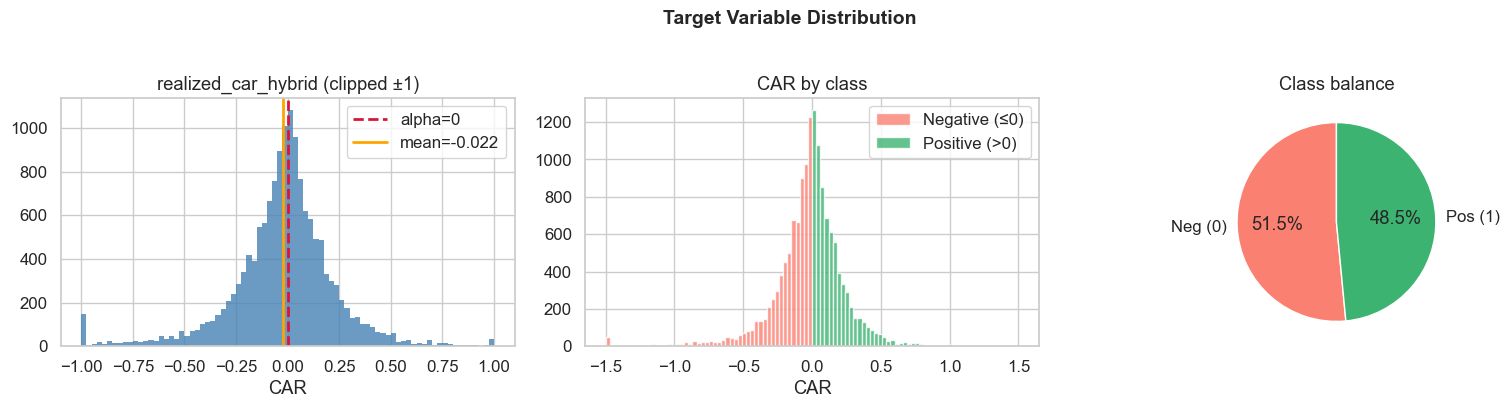

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Full distribution
ax = axes[0]
car = df['realized_car_hybrid'].clip(-1.0, 1.0)
ax.hist(car, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(0, color='crimson', lw=2, ls='--', label='alpha=0')
ax.axvline(car.mean(), color='orange', lw=2, ls='-', label=f'mean={car.mean():.3f}')
ax.set_title('realized_car_hybrid (clipped ±1)')
ax.set_xlabel('CAR')
ax.legend()

# Positive vs negative split
ax = axes[1]
pos = df.loc[df['alpha_above_threshold'] == 1, 'realized_car_hybrid'].clip(0, 1.5)
neg = df.loc[df['alpha_above_threshold'] == 0, 'realized_car_hybrid'].clip(-1.5, 0)
ax.hist(neg, bins=50, color='salmon', alpha=0.8, label='Negative (≤0)')
ax.hist(pos, bins=50, color='mediumseagreen', alpha=0.8, label='Positive (>0)')
ax.set_title('CAR by class')
ax.set_xlabel('CAR')
ax.legend()

# Class balance pie
ax = axes[2]
sizes = df['alpha_above_threshold'].value_counts().sort_index()
ax.pie(sizes, labels=['Neg (0)', 'Pos (1)'], autopct='%1.1f%%',
       colors=['salmon', 'mediumseagreen'], startangle=90)
ax.set_title('Class balance')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [6]:
# Target source: realized vs fallback
realized_mask = (
    (df['position_closed'] == True) &
    (df['holding_period_days'] <= 366) &
    (df['realized_car'].notna())
)
print('Target source breakdown:')
print(f'  realized_car (closed ≤12m): {realized_mask.sum():,} ({realized_mask.mean()*100:.1f}%)')
print(f'  car_filed_to_12m (fallback): {(~realized_mask).sum():,} ({(~realized_mask).mean()*100:.1f}%)')
print()
print('Positive rate by source:')
for label, mask in [('realized_car', realized_mask), ('car_filed_to_12m', ~realized_mask)]:
    subset = df[mask]
    if len(subset):
        pos_rate = (subset['alpha_above_threshold'] == 1).mean()
        print(f'  {label:<22}: {pos_rate:.1%}  (n={len(subset):,}, mean_car={subset["realized_car_hybrid"].mean():.4f})')

Target source breakdown:
  realized_car (closed ≤12m): 6,927 (45.8%)
  car_filed_to_12m (fallback): 8,190 (54.2%)

Positive rate by source:
  realized_car          : 47.1%  (n=6,927, mean_car=-0.0287)
  car_filed_to_12m      : 49.7%  (n=8,190, mean_car=-0.0235)


## 4. Numeric Features vs Target

In [7]:
NUMERIC_FEATS = [
    'log_trade_size', 'car_traded_to_filed',
    'politician_hit_rate_past', 'politician_mean_car_past',
    'politician_mean_realized_car_past',
    'stock_momentum_90d', 'stock_volatility_30d', 'beta',
    'max_committee_rank', 'n_committees',
    'all_pol_sells_same_ticker_30d', 'ticker_prior_buys',
    'politician_trades_last_year',
]

# Mean by class + t-test
rows = []
for col in NUMERIC_FEATS:
    if col not in df.columns:
        continue
    s = pd.to_numeric(df[col], errors='coerce')
    pos_vals = s[df['alpha_above_threshold'] == 1].dropna()
    neg_vals = s[df['alpha_above_threshold'] == 0].dropna()
    tstat, pval = stats.ttest_ind(pos_vals, neg_vals, equal_var=False)
    rows.append({
        'feature': col,
        'mean_positive': pos_vals.mean(),
        'mean_negative': neg_vals.mean(),
        'diff': pos_vals.mean() - neg_vals.mean(),
        'p_value': pval,
        'significant': '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else ''))
    })

summary = pd.DataFrame(rows).set_index('feature').sort_values('p_value')
summary.style.background_gradient(subset=['p_value'], cmap='RdYlGn_r').format({
    'mean_positive': '{:.4f}', 'mean_negative': '{:.4f}', 'diff': '{:.4f}', 'p_value': '{:.4f}'
})

,mean_positive,mean_negative,diff,p_value,significant
feature,,,,,
politician_hit_rate_past,0.5155,0.4942,0.0214,0.0000,***
all_pol_sells_same_ticker_30d,0.4855,0.3910,0.0945,0.0000,***
stock_momentum_90d,-0.0053,0.0107,-0.0160,0.0000,***
politician_mean_car_past,-0.0189,-0.0143,-0.0046,0.0000,***
beta,0.9908,1.0150,-0.0242,0.0001,***
n_committees,2.4686,2.3886,0.0800,0.0012,**
politician_mean_realized_car_past,-0.0404,-0.0351,-0.0053,0.0126,*
max_committee_rank,67.3196,74.5003,-7.1807,0.0780,
car_traded_to_filed,-0.0072,-0.0113,0.0041,0.1049,


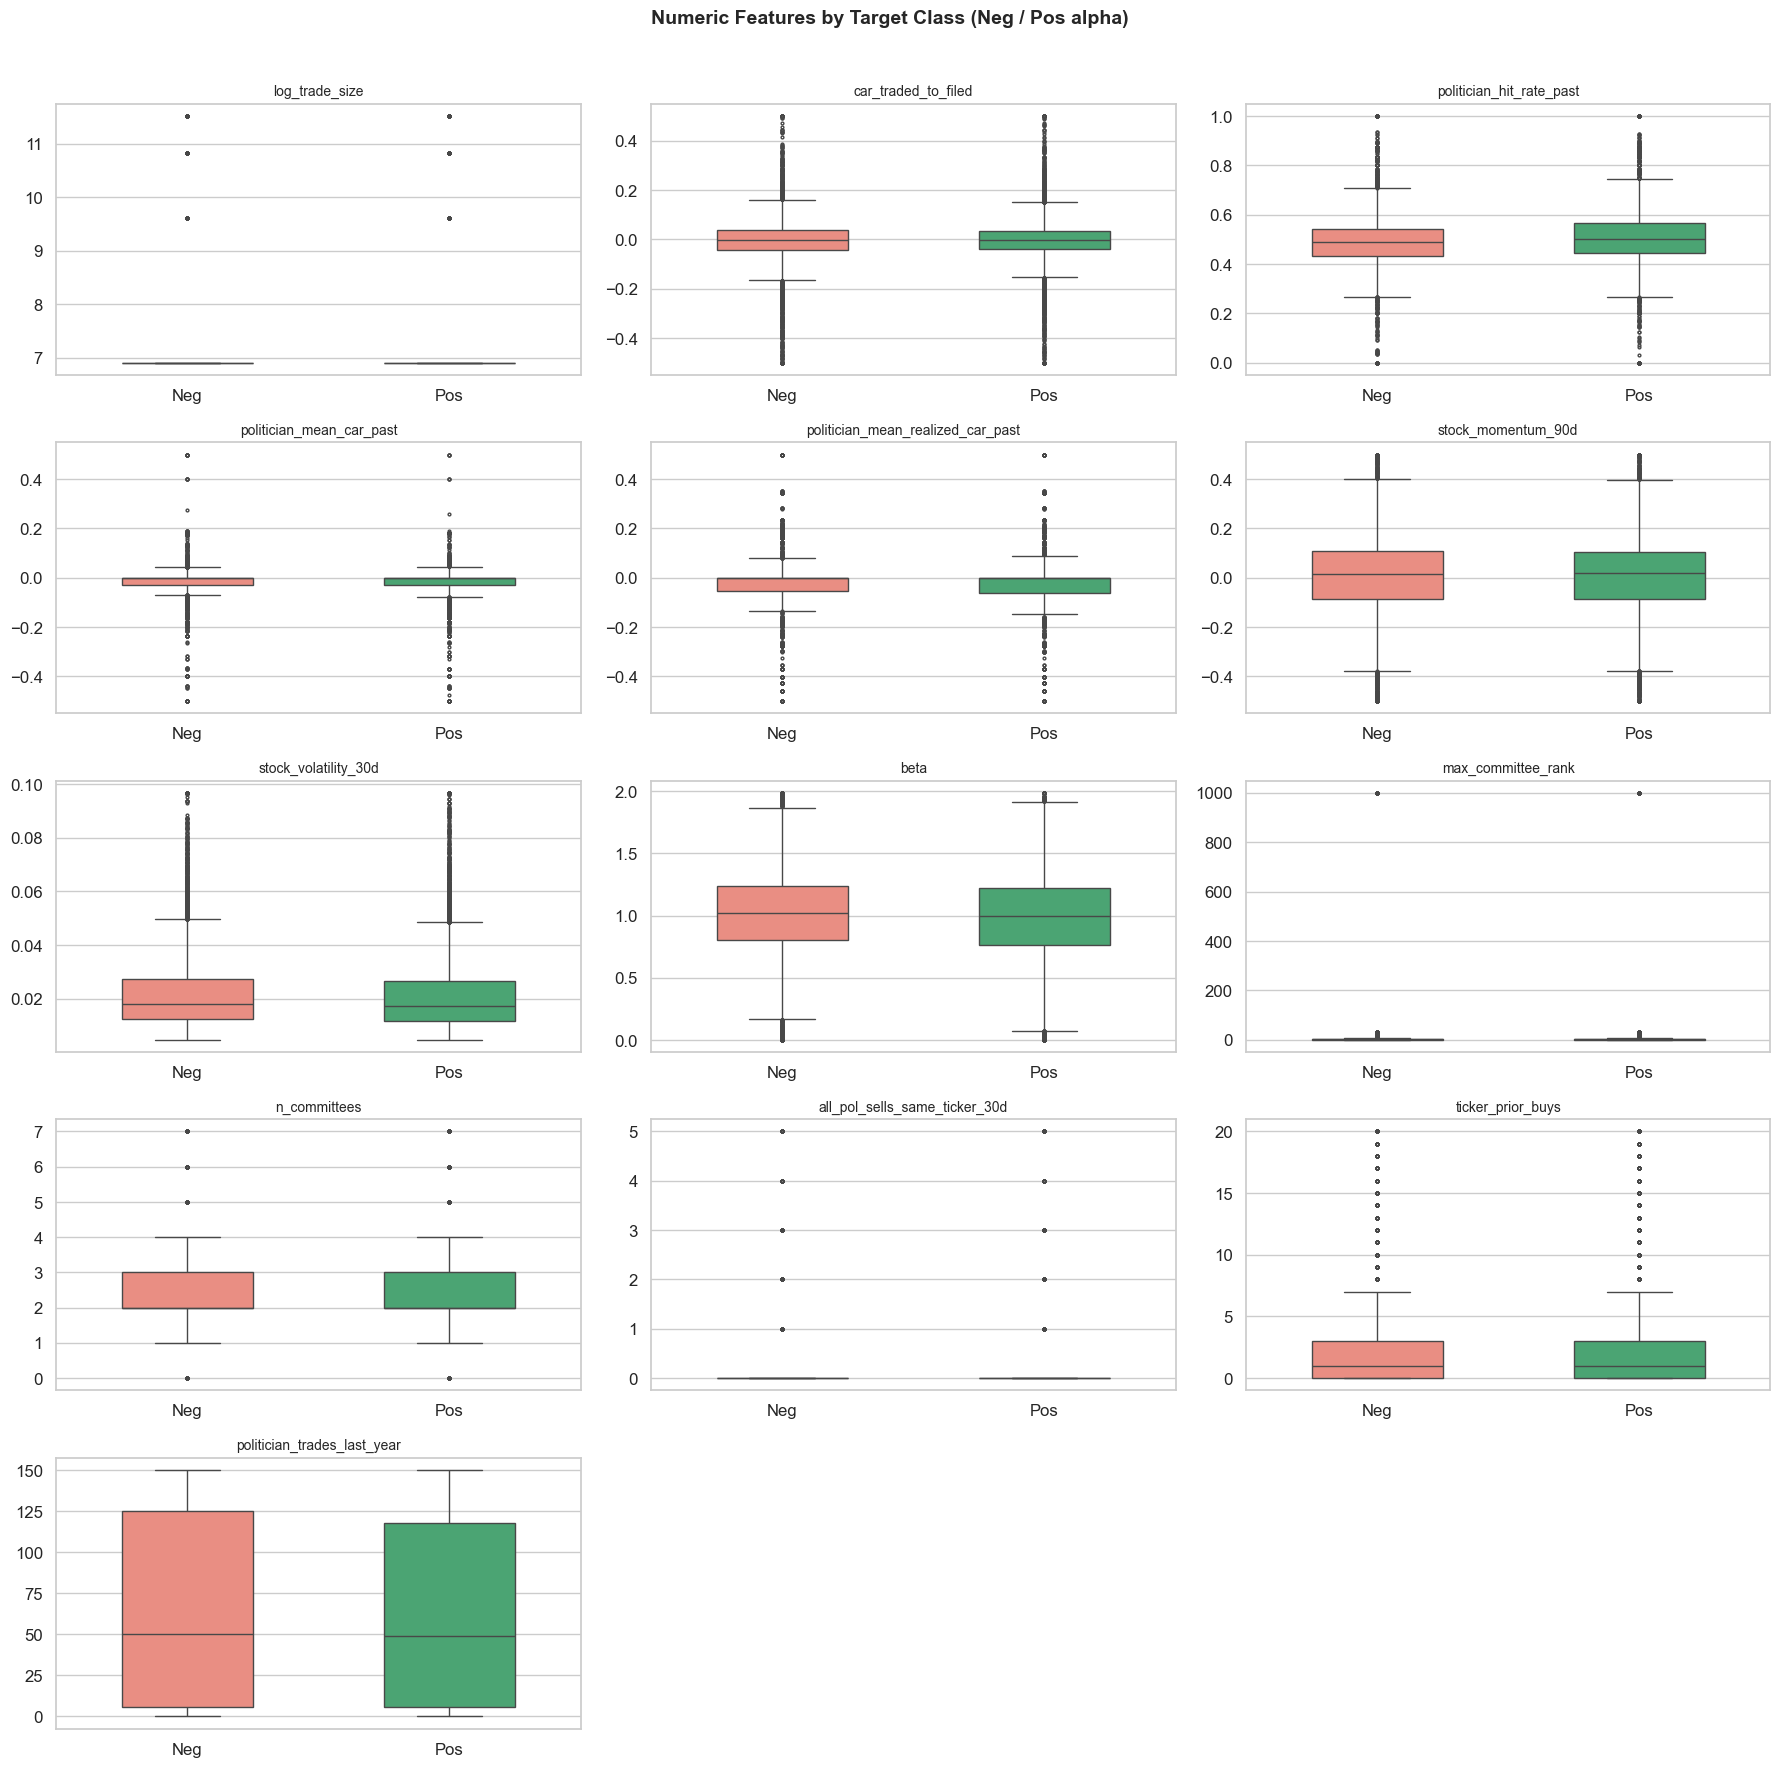

In [8]:
# Box plots: distribution by class for each numeric feature
n_cols = 3
n_rows = int(np.ceil(len(NUMERIC_FEATS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

CLIP_PARAMS = {
    'car_traded_to_filed': (-0.5, 0.5),
    'politician_mean_car_past': (-0.5, 0.5),
    'politician_mean_realized_car_past': (-0.5, 0.5),
    'stock_momentum_90d': (-0.5, 0.5),
    'all_pol_sells_same_ticker_30d': (0, 5),
    'ticker_prior_buys': (0, 20),
    'politician_trades_last_year': (0, 150),
}

for i, col in enumerate(NUMERIC_FEATS):
    ax = axes[i]
    if col not in df.columns:
        ax.set_visible(False)
        continue
    s = pd.to_numeric(df[col], errors='coerce')
    lo, hi = CLIP_PARAMS.get(col, (s.quantile(0.01), s.quantile(0.99)))
    plot_df = pd.DataFrame({'value': s.clip(lo, hi), 'label': df['alpha_above_threshold'].map({0: 'Neg', 1: 'Pos'})})
    sns.boxplot(data=plot_df, x='label', y='value', palette={'Neg': 'salmon', 'Pos': 'mediumseagreen'},
                ax=ax, order=['Neg', 'Pos'], width=0.5, fliersize=2)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Features by Target Class (Neg / Pos alpha)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 5. Correlation Matrix

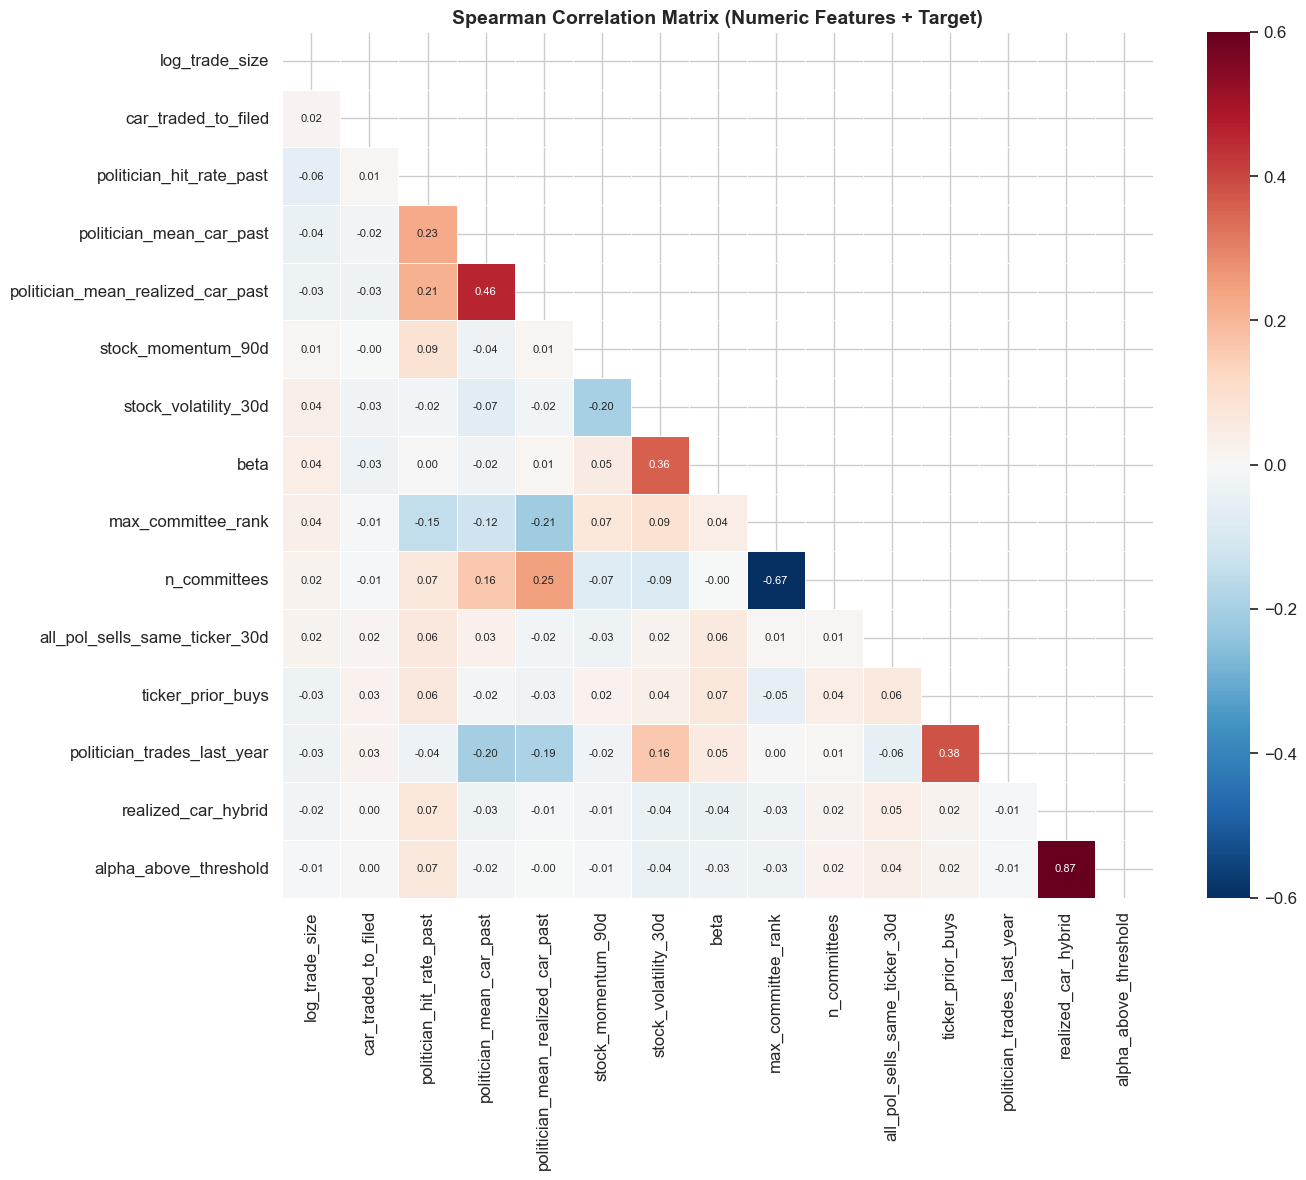

In [9]:
corr_cols = NUMERIC_FEATS + ['realized_car_hybrid', 'alpha_above_threshold']
corr_df = df[[c for c in corr_cols if c in df.columns]].apply(pd.to_numeric, errors='coerce')
corr = corr_df.corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-0.6, vmax=0.6, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Spearman Correlation Matrix (Numeric Features + Target)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Key Feature Deep Dives

### 6a. Politician hit rate vs realized CAR

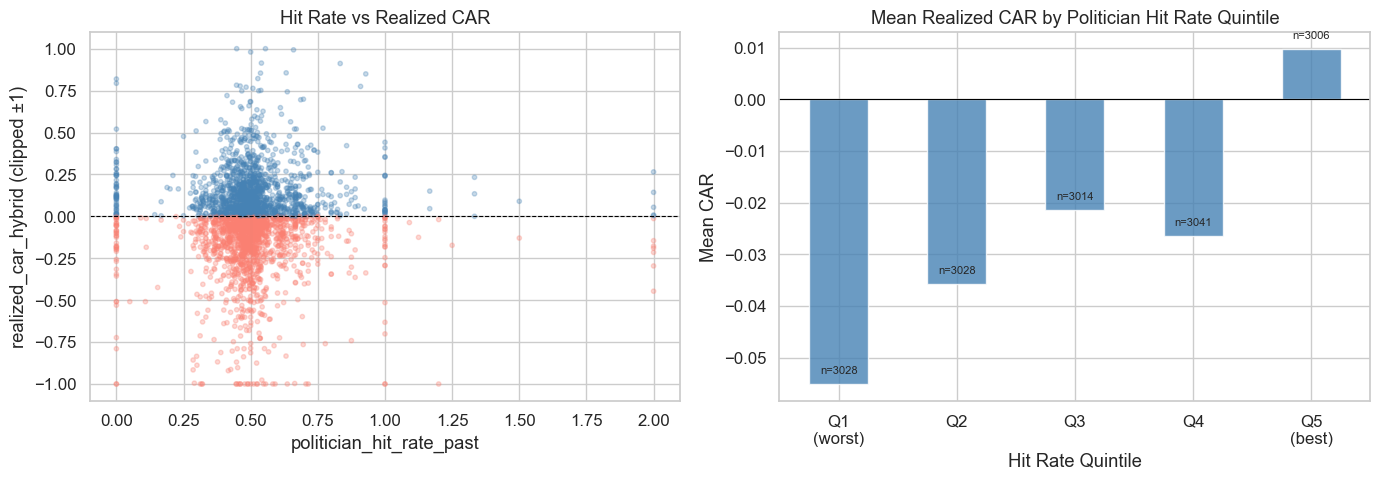

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: hit_rate vs realized_car
ax = axes[0]
sample = df.sample(min(3000, len(df)), random_state=42)
colors = sample['alpha_above_threshold'].map({0: 'salmon', 1: 'steelblue'})
ax.scatter(sample['politician_hit_rate_past'], sample['realized_car_hybrid'].clip(-1, 1),
           c=colors, alpha=0.3, s=10)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('politician_hit_rate_past')
ax.set_ylabel('realized_car_hybrid (clipped ±1)')
ax.set_title('Hit Rate vs Realized CAR')

# Quintile: mean realized_car by hit_rate quintile
ax = axes[1]
df['hit_rate_q'] = pd.qcut(df['politician_hit_rate_past'], q=5, labels=['Q1\n(worst)', 'Q2', 'Q3', 'Q4', 'Q5\n(best)'], duplicates='drop')
quint = df.groupby('hit_rate_q', observed=True)['realized_car_hybrid'].agg(['mean', 'median', 'count'])
quint['mean'].plot(kind='bar', ax=ax, color='steelblue', alpha=0.8, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticklabels(quint.index, rotation=0)
ax.set_title('Mean Realized CAR by Politician Hit Rate Quintile')
ax.set_ylabel('Mean CAR')
ax.set_xlabel('Hit Rate Quintile')
for j, (idx, row) in enumerate(quint.iterrows()):
    ax.text(j, row['mean'] + 0.002, f"n={int(row['count'])}", ha='center', fontsize=8)

plt.tight_layout()
plt.show()
df.drop(columns=['hit_rate_q'], inplace=True)

### 6b. Lobbying signal

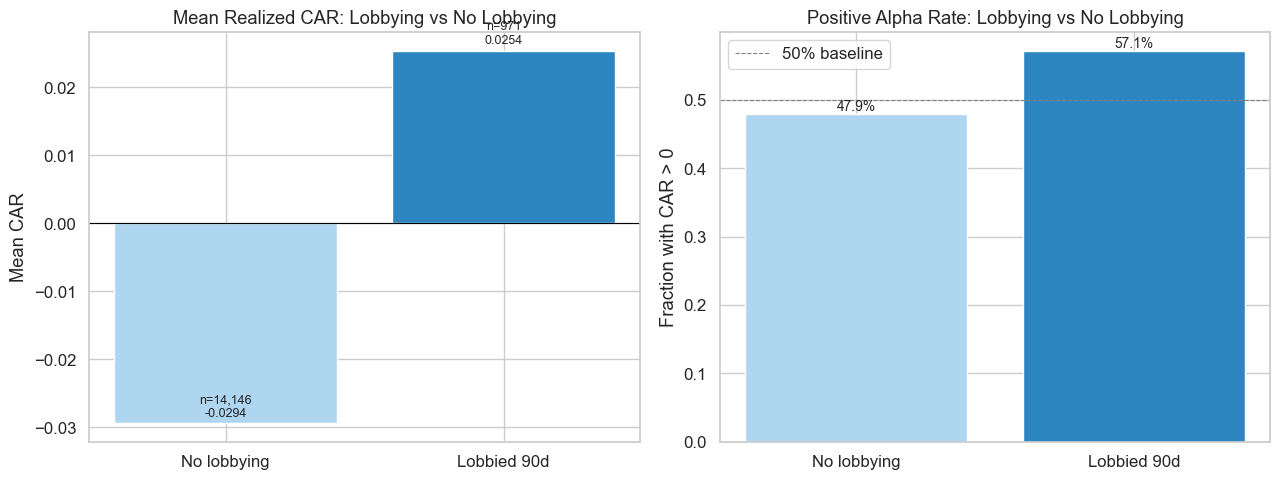

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lob_grp = df.groupby('lobbied_any_90d')['realized_car_hybrid'].agg(['mean', 'median', 'count', 'std'])
lob_grp.index = ['No lobbying', 'Lobbied 90d']

ax = axes[0]
bars = ax.bar(lob_grp.index, lob_grp['mean'], color=['#AED6F1', '#2E86C1'], edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
for bar, (idx, row) in zip(bars, lob_grp.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'n={int(row["count"]):,}\n{bar.get_height():.4f}', ha='center', fontsize=9)
ax.set_title('Mean Realized CAR: Lobbying vs No Lobbying')
ax.set_ylabel('Mean CAR')

ax = axes[1]
pos_rate = df.groupby('lobbied_any_90d')['alpha_above_threshold'].mean()
pos_rate.index = ['No lobbying', 'Lobbied 90d']
bars = ax.bar(pos_rate.index, pos_rate.values, color=['#AED6F1', '#2E86C1'], edgecolor='white')
ax.axhline(0.5, color='gray', lw=0.8, ls='--', label='50% baseline')
for bar, val in zip(bars, pos_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.1%}', ha='center', fontsize=10)
ax.set_title('Positive Alpha Rate: Lobbying vs No Lobbying')
ax.set_ylabel('Fraction with CAR > 0')
ax.legend()

plt.tight_layout()
plt.show()

### 6c. Committee flags vs target

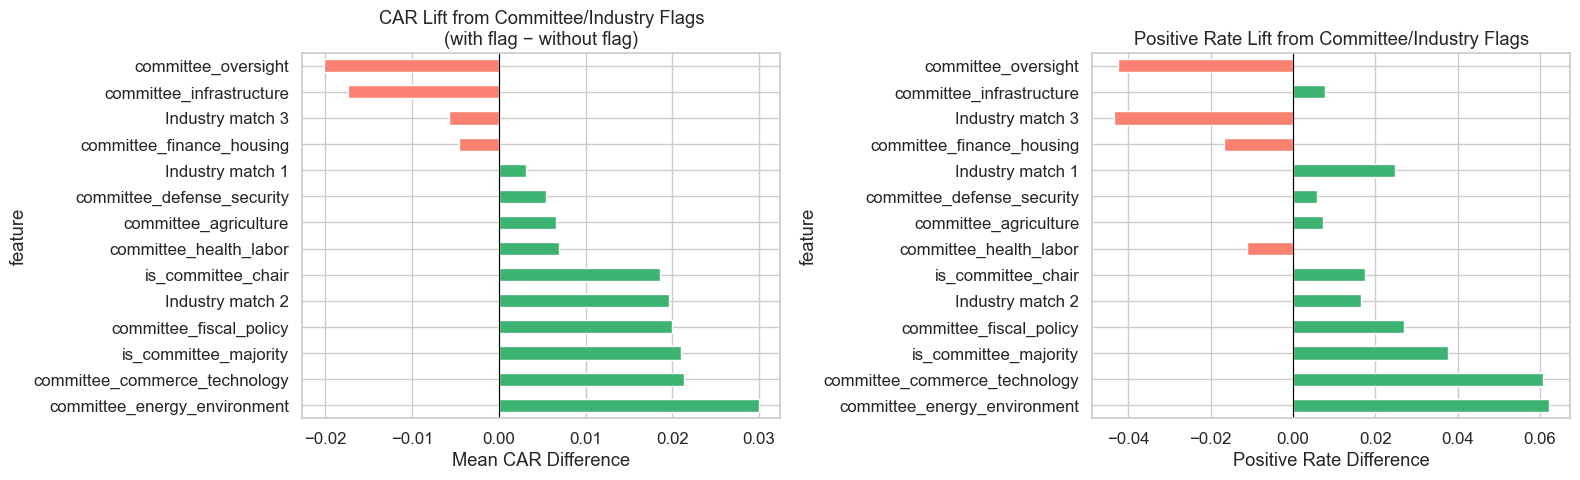

,n_with_flag,mean_car_with,mean_car_without,car_lift,pos_rate_with,pos_rate_without,pos_rate_lift
feature,,,,,,,
committee_energy_environment,2201,-0.0003,-0.0302,0.0299,0.5379,0.4758,0.0621
committee_commerce_technology,702,-0.0055,-0.0269,0.0213,0.5427,0.4821,0.0607
is_committee_majority,2434,-0.0083,-0.0292,0.0210,0.5164,0.4788,0.0376
committee_fiscal_policy,2219,-0.0089,-0.0288,0.0199,0.5079,0.4809,0.0270
Industry match 2,647,-0.0071,-0.0267,0.0196,0.5008,0.4842,0.0166
is_committee_chair,1406,-0.0090,-0.0276,0.0185,0.5007,0.4833,0.0174
committee_health_labor,2804,-0.0203,-0.0271,0.0069,0.4757,0.4870,-0.0112
committee_agriculture,2434,-0.0203,-0.0269,0.0066,0.4910,0.4837,0.0072
committee_defense_security,3490,-0.0216,-0.0271,0.0055,0.4894,0.4835,0.0059


In [12]:
committee_flags = [
    'committee_defense_security', 'committee_finance_housing',
    'committee_fiscal_policy', 'committee_energy_environment',
    'committee_health_labor', 'committee_commerce_technology',
    'committee_agriculture', 'committee_infrastructure', 'committee_oversight',
    'is_committee_majority', 'is_committee_chair',
    'Industry match 1', 'Industry match 2', 'Industry match 3',
]

rows = []
for col in committee_flags:
    if col not in df.columns:
        continue
    s = df[col].fillna(0).astype(float)
    has_flag = s == 1
    n_flag = has_flag.sum()
    if n_flag < 20:
        continue
    mean_car_with = df.loc[has_flag, 'realized_car_hybrid'].mean()
    mean_car_without = df.loc[~has_flag, 'realized_car_hybrid'].mean()
    pos_rate_with = df.loc[has_flag, 'alpha_above_threshold'].mean()
    pos_rate_without = df.loc[~has_flag, 'alpha_above_threshold'].mean()
    rows.append({
        'feature': col,
        'n_with_flag': n_flag,
        'mean_car_with': mean_car_with,
        'mean_car_without': mean_car_without,
        'car_lift': mean_car_with - mean_car_without,
        'pos_rate_with': pos_rate_with,
        'pos_rate_without': pos_rate_without,
        'pos_rate_lift': pos_rate_with - pos_rate_without,
    })

comm_df = pd.DataFrame(rows).set_index('feature').sort_values('car_lift', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
colors = ['mediumseagreen' if v > 0 else 'salmon' for v in comm_df['car_lift']]
comm_df['car_lift'].plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('CAR Lift from Committee/Industry Flags\n(with flag − without flag)')
ax.set_xlabel('Mean CAR Difference')

ax = axes[1]
colors = ['mediumseagreen' if v > 0 else 'salmon' for v in comm_df['pos_rate_lift']]
comm_df['pos_rate_lift'].plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Positive Rate Lift from Committee/Industry Flags')
ax.set_xlabel('Positive Rate Difference')

plt.tight_layout()
plt.show()
comm_df

### 6d. Stock momentum and volatility

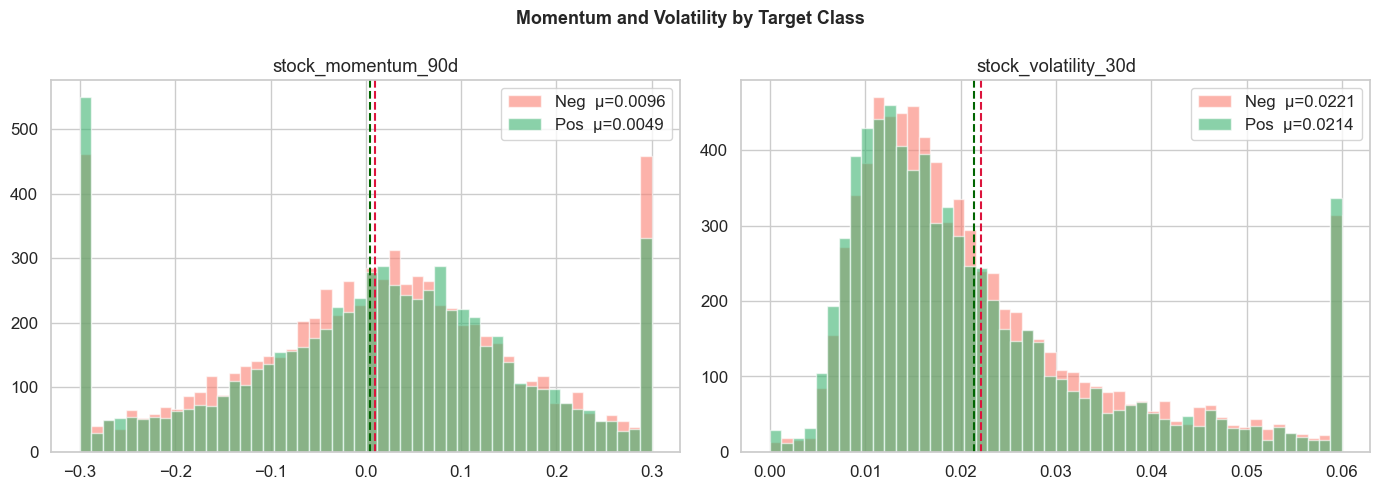

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, clip_lo, clip_hi in [
    (axes[0], 'stock_momentum_90d', -0.3, 0.3),
    (axes[1], 'stock_volatility_30d', 0, 0.06),
]:
    s = pd.to_numeric(df[col], errors='coerce').clip(clip_lo, clip_hi)
    pos_s = s[df['alpha_above_threshold'] == 1]
    neg_s = s[df['alpha_above_threshold'] == 0]
    ax.hist(neg_s.dropna(), bins=50, alpha=0.6, color='salmon', label=f'Neg  μ={neg_s.mean():.4f}')
    ax.hist(pos_s.dropna(), bins=50, alpha=0.6, color='mediumseagreen', label=f'Pos  μ={pos_s.mean():.4f}')
    ax.axvline(neg_s.mean(), color='crimson', lw=1.5, ls='--')
    ax.axvline(pos_s.mean(), color='darkgreen', lw=1.5, ls='--')
    ax.set_title(col)
    ax.legend()

plt.suptitle('Momentum and Volatility by Target Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Categorical Features vs Target

In [14]:
def plot_cat_vs_target(col, top_n=15, figsize=(14, 5)):
    if col not in df.columns:
        print(f'{col} not in df')
        return
    grp = df.groupby(col, observed=True).agg(
        n=('alpha_above_threshold', 'count'),
        pos_rate=('alpha_above_threshold', 'mean'),
        mean_car=('realized_car_hybrid', 'mean'),
    ).sort_values('n', ascending=False).head(top_n)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    ax = axes[0]
    colors = ['mediumseagreen' if v > grp['pos_rate'].mean() else 'salmon' for v in grp['pos_rate']]
    grp['pos_rate'].plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.axhline(df['alpha_above_threshold'].mean(), color='gray', ls='--', lw=1, label='Overall avg')
    ax.set_title(f'{col} — Positive Rate')
    ax.set_ylabel('Fraction with CAR > 0')
    ax.set_xticklabels(grp.index, rotation=35, ha='right', fontsize=9)
    ax.legend()

    ax = axes[1]
    colors = ['mediumseagreen' if v > 0 else 'salmon' for v in grp['mean_car']]
    grp['mean_car'].plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.axhline(0, color='black', lw=0.8)
    ax.axhline(df['realized_car_hybrid'].mean(), color='gray', ls='--', lw=1, label='Overall avg')
    ax.set_title(f'{col} — Mean Realized CAR')
    ax.set_ylabel('Mean CAR')
    ax.set_xticklabels(grp.index, rotation=35, ha='right', fontsize=9)
    ax.legend()

    plt.tight_layout()
    plt.show()
    return grp

=== Party ===


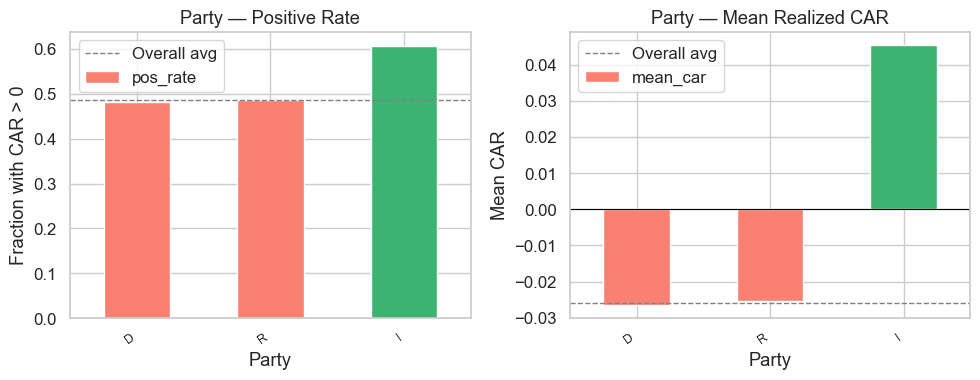

,n,pos_rate,mean_car
Party,,,
D,7688,0.4824,-0.0265
R,7401,0.4870,-0.0254
I,28,0.6071,0.0455


In [15]:
# Party
print('=== Party ===')
plot_cat_vs_target('Party', top_n=5, figsize=(10, 4))

=== Chamber ===


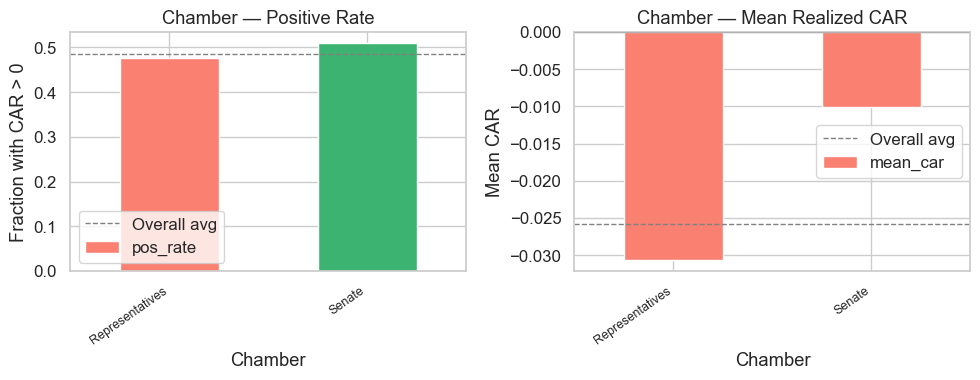

,n,pos_rate,mean_car
Chamber,,,
Representatives,11616,0.4775,-0.0306
Senate,3501,0.5093,-0.0101


In [16]:
# Chamber
print('=== Chamber ===')
plot_cat_vs_target('Chamber', top_n=5, figsize=(10, 4))

=== Ticker_Sector ===


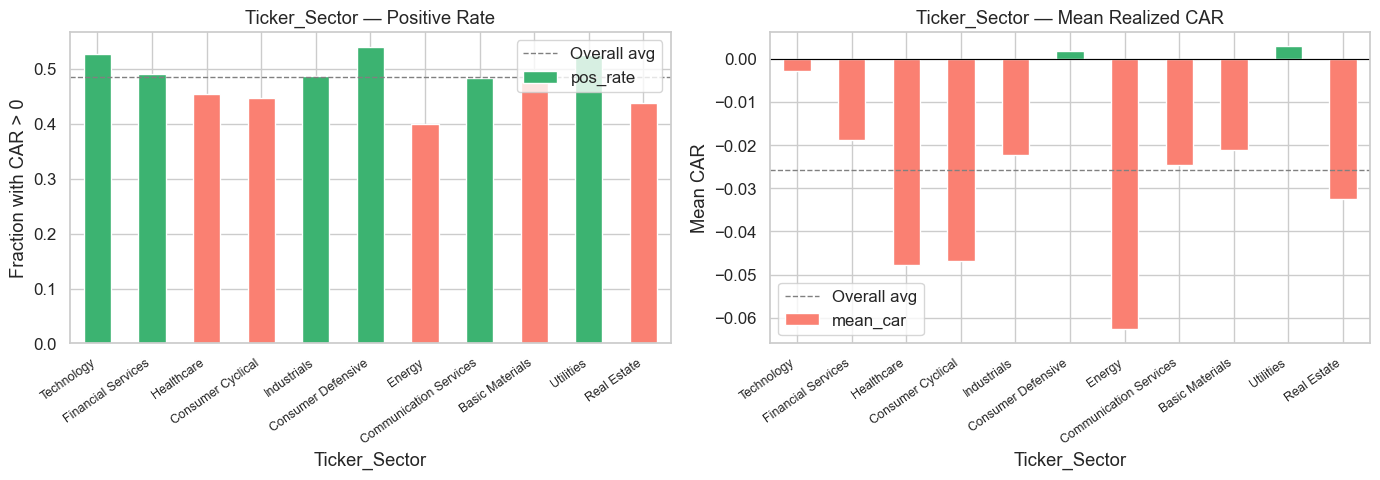

,n,pos_rate,mean_car
Ticker_Sector,,,
Technology,2406,0.5270,-0.0028
Financial Services,1819,0.4909,-0.0189
Healthcare,1767,0.4533,-0.0478
Consumer Cyclical,1639,0.4460,-0.0468
Industrials,1492,0.4859,-0.0223
Consumer Defensive,1080,0.5398,0.0017
Energy,1070,0.4000,-0.0627
Communication Services,957,0.4828,-0.0247
Basic Materials,542,0.4760,-0.0211


In [17]:
# Sector
print('=== Ticker_Sector ===')
plot_cat_vs_target('Ticker_Sector', top_n=12)

=== Ticker_Industry (top 20 by trade count) ===


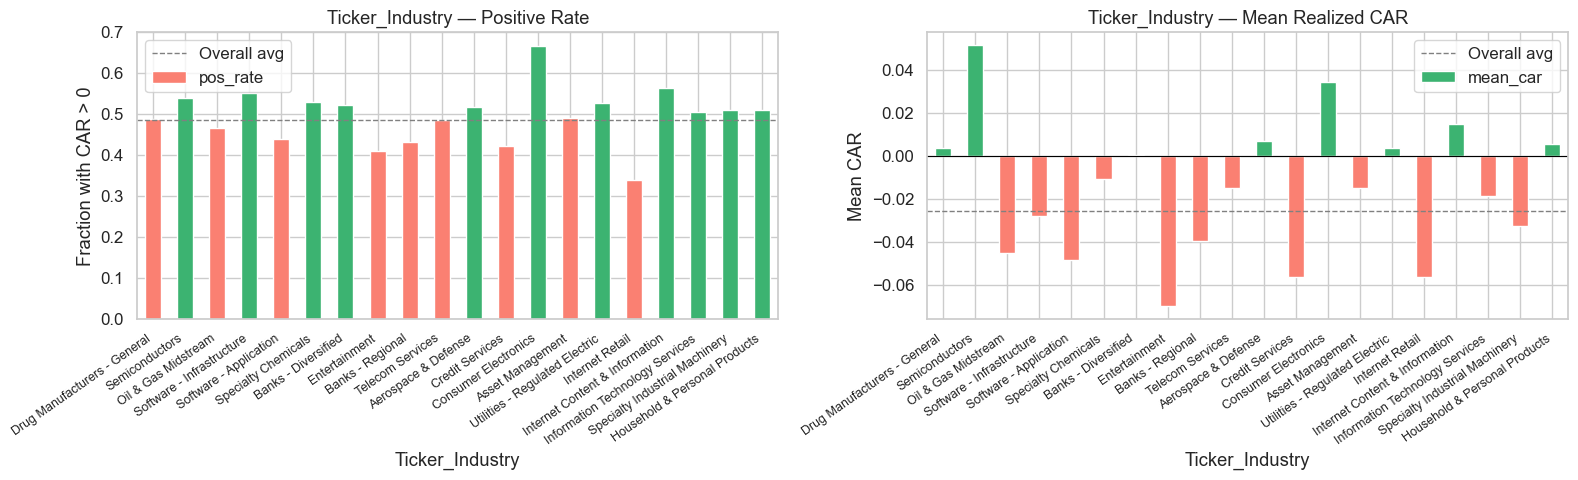

,n,pos_rate,mean_car
Ticker_Industry,,,
Drug Manufacturers - General,626,0.4872,0.0037
Semiconductors,564,0.5390,0.0515
Oil & Gas Midstream,508,0.4646,-0.0455
Software - Infrastructure,439,0.5513,-0.0280
Software - Application,358,0.4385,-0.0485
Specialty Chemicals,332,0.5301,-0.0109
Banks - Diversified,326,0.5215,0.0004
Entertainment,310,0.4097,-0.0699
Banks - Regional,306,0.4314,-0.0397


In [18]:
# Top industries
print('=== Ticker_Industry (top 20 by trade count) ===')
plot_cat_vs_target('Ticker_Industry', top_n=20, figsize=(16, 5))

=== Lag Bucket (trade → filing delay) ===


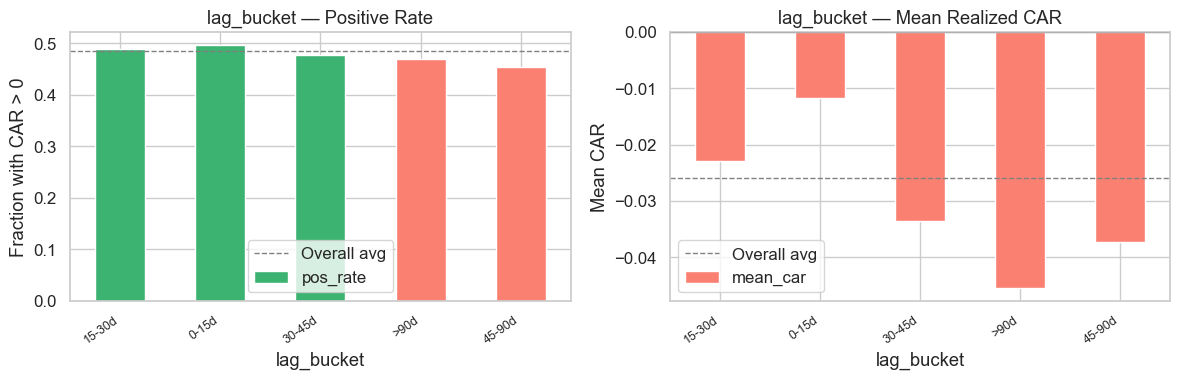

,n,pos_rate,mean_car
lag_bucket,,,
15-30d,5414,0.4898,-0.0230
0-15d,3751,0.4975,-0.0117
30-45d,3434,0.4782,-0.0335
>90d,1683,0.4694,-0.0454
45-90d,835,0.4551,-0.0373


In [19]:
# Filing lag bucket
print('=== Lag Bucket (trade → filing delay) ===')
plot_cat_vs_target('lag_bucket', top_n=10, figsize=(12, 4))

## 8. Top Politicians

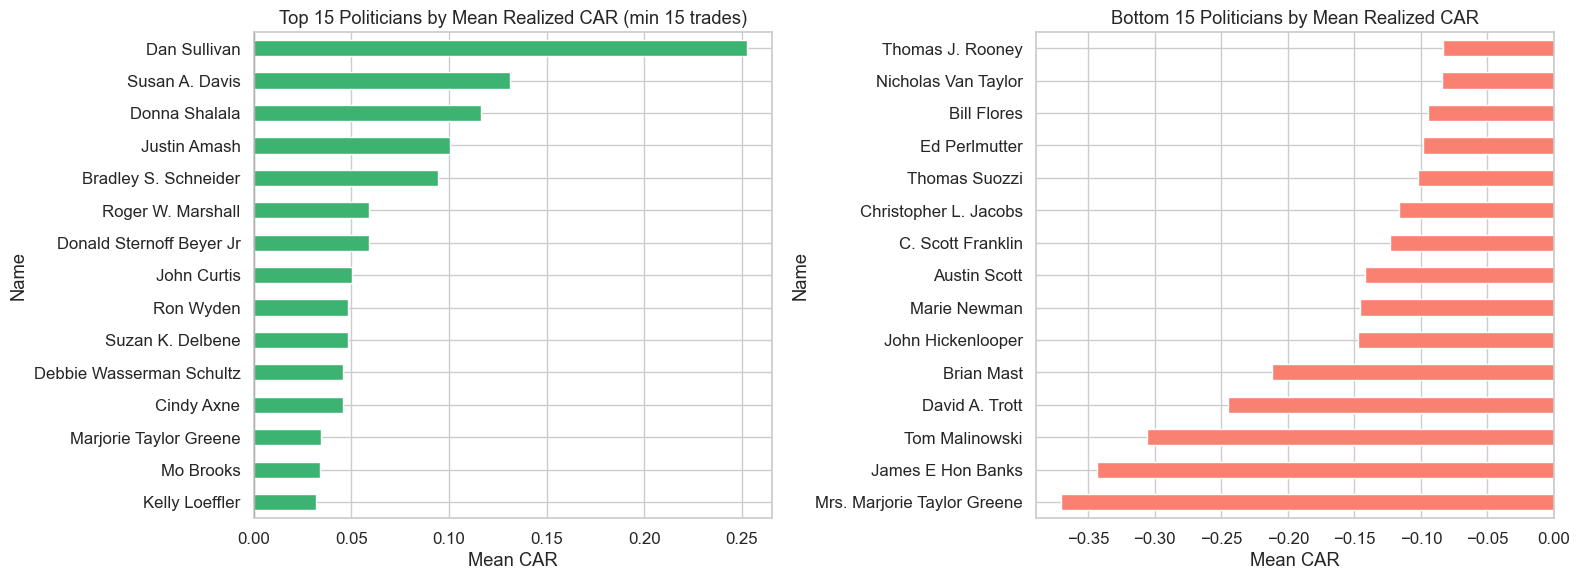

,n_trades,hit_rate,mean_car,mean_realized_car
Name,,,,
Dan Sullivan,35,0.8286,0.2526,0.0000
Susan A. Davis,16,0.6250,0.1313,0.0420
Donna Shalala,143,0.5874,0.1164,0.0000
Justin Amash,18,0.7222,0.1005,0.0000
Bradley S. Schneider,22,0.6818,0.0946,-0.0500
Roger W. Marshall,46,0.6087,0.0589,-0.0113
Donald Sternoff Beyer Jr,299,0.6355,0.0589,0.0174
John Curtis,123,0.5122,0.0503,0.1273
Ron Wyden,179,0.6145,0.0482,-0.0254


In [20]:
pol = df.groupby('Name').agg(
    n_trades=('alpha_above_threshold', 'count'),
    hit_rate=('alpha_above_threshold', 'mean'),
    mean_car=('realized_car_hybrid', 'mean'),
    mean_realized_car=('politician_mean_realized_car_past', 'mean'),
).query('n_trades >= 15').sort_values('mean_car', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
top15 = pol.head(15)
colors = ['mediumseagreen' if v > 0 else 'salmon' for v in top15['mean_car']]
top15['mean_car'].plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Top 15 Politicians by Mean Realized CAR (min 15 trades)')
ax.set_xlabel('Mean CAR')
ax.invert_yaxis()

ax = axes[1]
bottom15 = pol.tail(15)
colors = ['mediumseagreen' if v > 0 else 'salmon' for v in bottom15['mean_car']]
bottom15['mean_car'].plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Bottom 15 Politicians by Mean Realized CAR')
ax.set_xlabel('Mean CAR')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

pol.head(20)

## 9. Time Trends

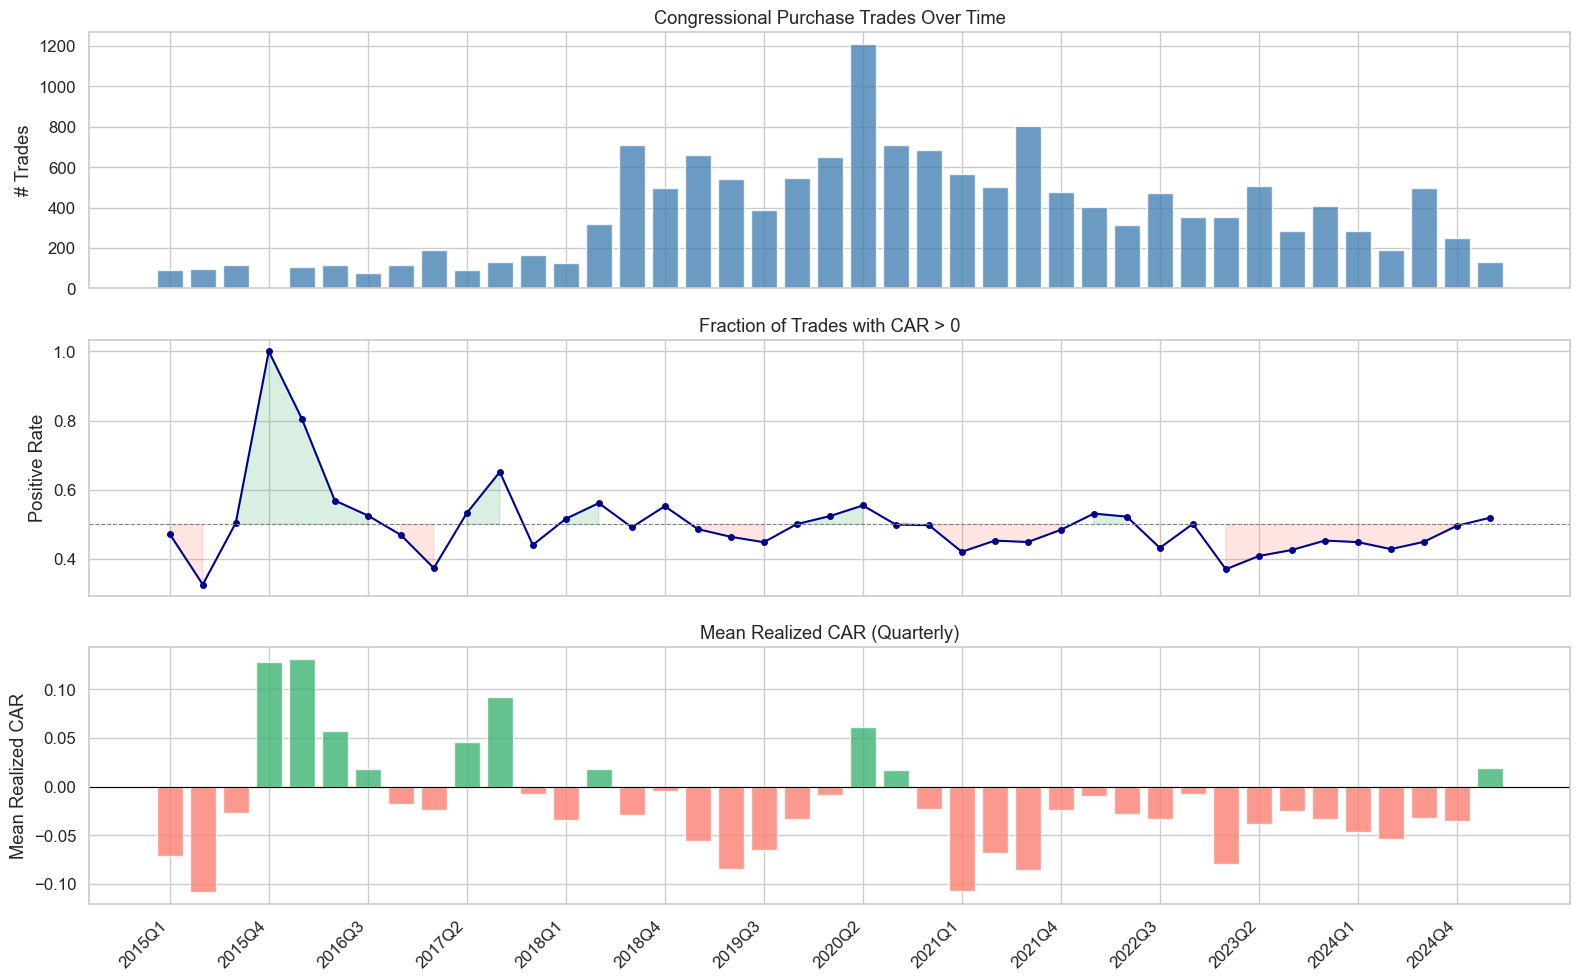

In [21]:
df['year_quarter'] = df['Filed'].dt.to_period('Q')

time_grp = df.groupby('year_quarter', observed=True).agg(
    n_trades=('alpha_above_threshold', 'count'),
    pos_rate=('alpha_above_threshold', 'mean'),
    mean_car=('realized_car_hybrid', 'mean'),
).sort_index()

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

ax = axes[0]
ax.bar(range(len(time_grp)), time_grp['n_trades'], color='steelblue', alpha=0.8)
ax.set_ylabel('# Trades')
ax.set_title('Congressional Purchase Trades Over Time')

ax = axes[1]
ax.plot(range(len(time_grp)), time_grp['pos_rate'], color='darkblue', marker='o', ms=4)
ax.axhline(0.5, color='gray', lw=0.8, ls='--')
ax.fill_between(range(len(time_grp)), 0.5, time_grp['pos_rate'],
                where=time_grp['pos_rate'] > 0.5, alpha=0.2, color='mediumseagreen')
ax.fill_between(range(len(time_grp)), 0.5, time_grp['pos_rate'],
                where=time_grp['pos_rate'] < 0.5, alpha=0.2, color='salmon')
ax.set_ylabel('Positive Rate')
ax.set_title('Fraction of Trades with CAR > 0')

ax = axes[2]
colors = ['mediumseagreen' if v > 0 else 'salmon' for v in time_grp['mean_car']]
ax.bar(range(len(time_grp)), time_grp['mean_car'], color=colors, alpha=0.8)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Mean Realized CAR')
ax.set_title('Mean Realized CAR (Quarterly)')

tick_step = max(1, len(time_grp) // 12)
ax.set_xticks(range(0, len(time_grp), tick_step))
ax.set_xticklabels([str(p) for p in time_grp.index[::tick_step]], rotation=45, ha='right')

plt.tight_layout()
plt.show()
df.drop(columns=['year_quarter'], inplace=True)

## 10. Holding Period Analysis

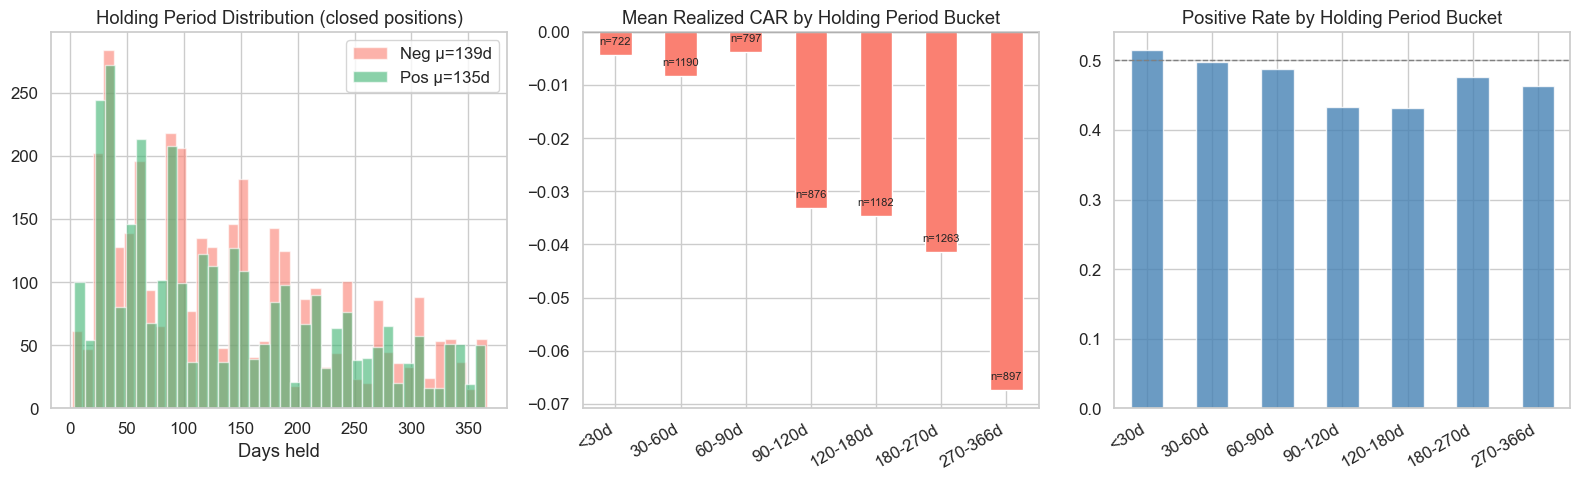

In [22]:
closed = df[df['position_closed'] == True].copy()
closed['hold_days'] = pd.to_numeric(closed['holding_period_days'], errors='coerce')
closed['hold_bucket'] = pd.cut(closed['hold_days'],
    bins=[0, 30, 60, 90, 120, 180, 270, 366],
    labels=['<30d', '30-60d', '60-90d', '90-120d', '120-180d', '180-270d', '270-366d'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
pos_hold = closed.loc[closed['alpha_above_threshold'] == 1, 'hold_days'].clip(0, 366)
neg_hold = closed.loc[closed['alpha_above_threshold'] == 0, 'hold_days'].clip(0, 366)
ax.hist(neg_hold.dropna(), bins=40, alpha=0.6, color='salmon', label=f'Neg μ={neg_hold.mean():.0f}d')
ax.hist(pos_hold.dropna(), bins=40, alpha=0.6, color='mediumseagreen', label=f'Pos μ={pos_hold.mean():.0f}d')
ax.set_title('Holding Period Distribution (closed positions)')
ax.set_xlabel('Days held')
ax.legend()

ax = axes[1]
hb = closed.groupby('hold_bucket', observed=True).agg(
    mean_car=('realized_car_hybrid', 'mean'),
    n=('alpha_above_threshold', 'count')
)
colors = ['mediumseagreen' if v > 0 else 'salmon' for v in hb['mean_car']]
hb['mean_car'].plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
for j, (idx, row) in enumerate(hb.iterrows()):
    ax.text(j, row['mean_car'] + 0.002, f'n={int(row["n"])}', ha='center', fontsize=8)
ax.set_title('Mean Realized CAR by Holding Period Bucket')
ax.set_xlabel('')
ax.set_xticklabels(hb.index, rotation=30, ha='right')

ax = axes[2]
hb_pos = closed.groupby('hold_bucket', observed=True)['alpha_above_threshold'].mean()
hb_pos.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', alpha=0.8)
ax.axhline(0.5, color='gray', ls='--', lw=1)
ax.set_title('Positive Rate by Holding Period Bucket')
ax.set_xlabel('')
ax.set_xticklabels(hb_pos.index, rotation=30, ha='right')

plt.tight_layout()
plt.show()

## 11. Trade Size vs Target

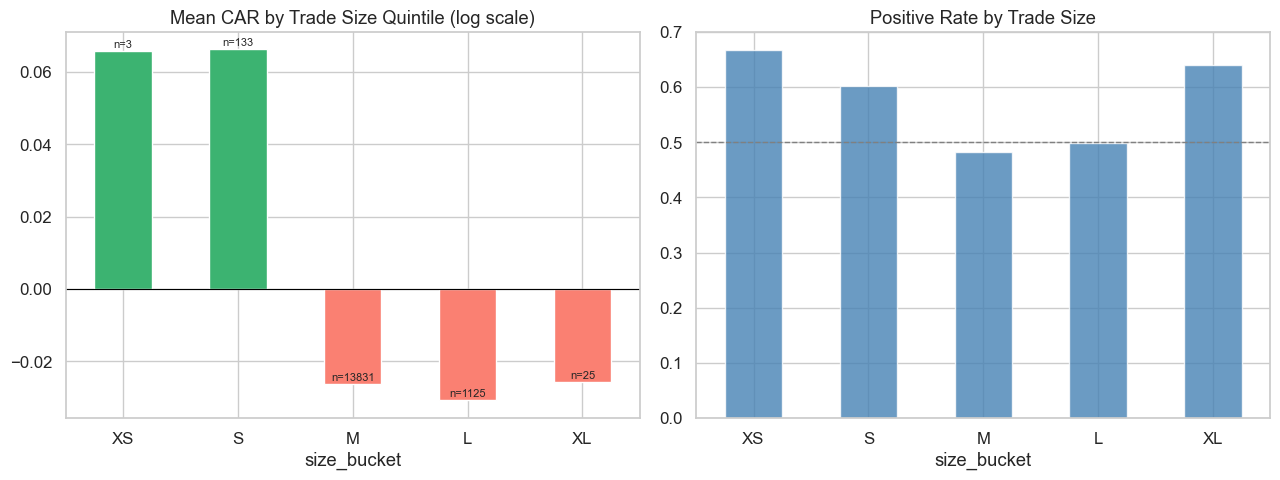

In [23]:
df['size_bucket'] = pd.cut(df['log_trade_size'],
    bins=5,
    labels=['XS', 'S', 'M', 'L', 'XL'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sz = df.groupby('size_bucket', observed=True).agg(
    mean_car=('realized_car_hybrid', 'mean'),
    pos_rate=('alpha_above_threshold', 'mean'),
    n=('alpha_above_threshold', 'count'),
)

ax = axes[0]
colors = ['mediumseagreen' if v > 0 else 'salmon' for v in sz['mean_car']]
sz['mean_car'].plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.axhline(0, color='black', lw=0.8)
for j, (idx, row) in enumerate(sz.iterrows()):
    ax.text(j, row['mean_car'] + 0.001, f'n={int(row["n"])}', ha='center', fontsize=8)
ax.set_title('Mean CAR by Trade Size Quintile (log scale)')
ax.set_xticklabels(sz.index, rotation=0)

ax = axes[1]
sz['pos_rate'].plot(kind='bar', ax=ax, color='steelblue', edgecolor='white', alpha=0.8)
ax.axhline(0.5, color='gray', ls='--', lw=1)
ax.set_title('Positive Rate by Trade Size')
ax.set_xticklabels(sz.index, rotation=0)

plt.tight_layout()
plt.show()
df.drop(columns=['size_bucket'], inplace=True)

## 12. Summary: Feature Predictive Power Ranking

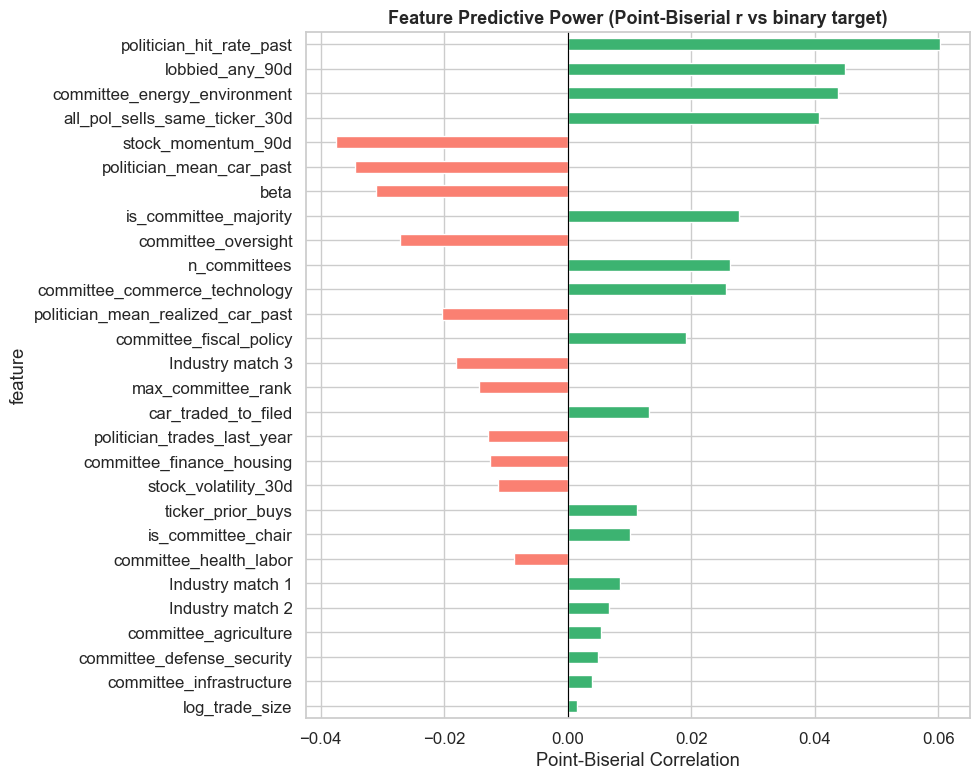

,point_biserial_r,p_value
feature,,
politician_hit_rate_past,0.0603,0.0000
lobbied_any_90d,0.0449,0.0000
committee_energy_environment,0.0438,0.0000
all_pol_sells_same_ticker_30d,0.0408,0.0000
stock_momentum_90d,-0.0375,0.0000
politician_mean_car_past,-0.0344,0.0000
beta,-0.0311,0.0001
is_committee_majority,0.0277,0.0007
committee_oversight,-0.0272,0.0008


In [24]:
from scipy.stats import pointbiserialr

y = df['alpha_above_threshold'].astype(float)

all_feats = NUMERIC_FEATS + [
    'lobbied_any_90d', 'is_committee_majority', 'is_committee_chair',
    'Industry match 1', 'Industry match 2', 'Industry match 3',
    'committee_defense_security', 'committee_finance_housing',
    'committee_fiscal_policy', 'committee_energy_environment',
    'committee_health_labor', 'committee_commerce_technology',
    'committee_agriculture', 'committee_infrastructure', 'committee_oversight',
]

power_rows = []
for col in all_feats:
    if col not in df.columns:
        continue
    s = pd.to_numeric(df[col], errors='coerce')
    valid = s.notna() & y.notna()
    if valid.sum() < 50:
        continue
    r, pval = pointbiserialr(s[valid], y[valid])
    power_rows.append({'feature': col, 'point_biserial_r': r, 'p_value': pval, 'abs_r': abs(r)})

power_df = pd.DataFrame(power_rows).set_index('feature').sort_values('abs_r', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['mediumseagreen' if v > 0 else 'salmon' for v in power_df['point_biserial_r']]
power_df['point_biserial_r'].plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Feature Predictive Power (Point-Biserial r vs binary target)', fontsize=13, fontweight='bold')
ax.set_xlabel('Point-Biserial Correlation')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

power_df[['point_biserial_r', 'p_value']].round(5)